In [28]:
libraries = c("dplyr", "tidyverse", "magrittr", "ggplot2", "zoo", "rstan")
for(x in libraries) {library(x,character.only = TRUE, warn.conflicts = FALSE, quietly = TRUE)}
theme_set(theme_bw())

options(scipen = 999)

In [29]:
source("seroprev_varying_FoI_comparison.r")

In [30]:
## settings
target_foi <- c(3, 1, 0.1)
foi_profile_list <- lapply(target_foi * .01, rep, times = group_num)
sample <- 1000

# Age-varying FoI catalytic model

In [31]:
rstan_options(auto_write = TRUE)
options(mc.cores = parallel::detectCores())
rstan_options(threads_per_chain = 1)

In [32]:
## naive discrete catalytic model for age-group FoI estimates
naive_model_group = "
data {
    int<lower=1> N;
    array[N] int<lower=0> n_positive;
    array[N] int<lower=0> n_sample;
    vector[N] age_lower;
    vector[N] age_upper;
    vector<lower=1e-8>[N] foi_prior_median;
}

parameters {
    vector<lower=1e-8>[N] foi; // FOI by age-bin
}

transformed parameters {
    vector[N] prev_hat;
    real eps = 1e-12;

    vector[N] w;
    real H_start; // cumulative hazard at start of bin

    for (i in 1:N)
        w[i] = age_upper[i] - age_lower[i];

    H_start = 0;

    for (i in 1:N) {
        real wi = w[i];
        real lam = foi[i];

        real x = lam * wi;
        real one_minus_uw = -expm1(-x);

        real raw_prev = 1 - exp(-H_start) * (one_minus_uw / x);

        prev_hat[i] = fmin(fmax(raw_prev, eps), 1 - eps);
        H_start += x; // since x = lam * wi
    }
}

model {
    for(i in 1:N) {foi[i] ~ lognormal(log(foi_prior_median[i]), 0.7);}
    n_positive ~ binomial(n_sample, prev_hat);
    
}
"

In [33]:
## adjusted discrete catalytic model for age-group FoI estimates
adjust_model_group = "
data {
    int<lower=1> N;
    array[N] int<lower=0> n_positive;
    array[N] int<lower=0> n_sample;
    vector[N] age_lower;
    vector[N] age_upper;
    vector<lower=0, upper=1>[N] ifr_profile;
    vector<lower=1e-8>[N] foi_prior_median;
}

parameters {
    vector<lower=1e-8>[N] foi; // FOI by age-bin
}

transformed parameters {
    vector[N] prev_hat;
    real eps = 1e-12;
    
    vector[N] w;
    real surv_start;
    real H_start;

    for (i in 1:N)
        w[i] = age_upper[i] - age_lower[i];

    surv_start = 0;
    H_start = 0;

    for (i in 1:N) {
        real A = surv_start;
        real lam = foi[i];
        real wi = w[i];
        real IFR = ifr_profile[i];
        
        real C = exp(-H_start);
        real x = lam * wi;
        real uw = exp(-x);
        real one_minus_uw = -expm1(-x);

        real raw_prev;

        if (IFR < 1e-8) {
            real denom = A + C;
            raw_prev = 1 - (C / denom) * one_minus_uw / x;
        } else {
            real denom0 = A + C;
            real denom1 = A + C * (1 - IFR) + C * IFR * uw;

            real log_ratio = -log1p( (denom1 - denom0) / denom0 );
            raw_prev = 1 - (1 / (x * IFR)) * log_ratio;
        }

        prev_hat[i] = fmin(fmax(raw_prev, eps), 1 - eps);
        surv_start += C * one_minus_uw * (1 - IFR);
        H_start += x;
    }
}

model {
    for (i in 1:N) {foi[i] ~ lognormal(log(foi_prior_median[i]), 0.7);}
    n_positive ~ binomial(n_sample, prev_hat);
}
"

In [42]:
## compiling
sm_naive  <- stan_model(model_code = naive_model_group)
sm_adjust <- stan_model(model_code = adjust_model_group)

# sampling
run_catalytic_group <- function(sm, stan_data, init_val = 0.01) {
    N <- stan_data$N
    init_vec <- if (length(init_val) == 1) rep(init_val, N) else init_val
    fit <- sampling(object = sm, data = stan_data,
                    chains = 4, iter = 5000, warmup = 1000, thin = 1,
                    control = list(adapt_delta = 0.99, max_treedepth = 12),
                    init = function() list(foi = init_vec))
  
    smry <- summary(fit, pars = "foi")$summary
    out <- data.frame(param = rownames(smry), idx = as.integer(gsub("foi\\[|\\]", "", rownames(smry))),
                      est_med = smry[, "50%"], est_lower = smry[, "2.5%"], est_25 = smry[, "25%"],
                      est_75 = smry[, "75%"], est_upper = smry[, "97.5%"], row.names = NULL)
   
    return(list(fit = fit, summary = out))
}

## containers
plots_naive_list <- replicate(3, vector("list", 3), simplify = FALSE)
plots_adjusted_list <- replicate(3, vector("list", 3), simplify = FALSE)
estimates_naive <- replicate(3, vector("list", 3), simplify = FALSE)
estimates_adjusted <- replicate(3, vector("list", 3), simplify = FALSE)

## estimation
foi_index_for_ifr <- c("Decreasing IFR" = 1, "U-shaped IFR" = 2, "Increasing IFR" = 3)

for (i in seq_along(IFR_class)) {
    this_ifr_class <- trimws(as.character(IFR_class[i]))
    foi_idx <- as.integer(unname(foi_index_for_ifr[this_ifr_class]))

    for (l in seq_along(target_IFR)) {
        ## observed sero data
        ifr_profile <- ifr_profile_scale_list[[i]][[l]]

        observed_df <- plot_data %>% 
        filter(scenario  == paste0(IFR_class[g], " & ", foi_class[k]), 
               ifr_level == paste0("IFR (", target_IFR[l], "%)"), 
               Group == "Observed") %>%
        mutate(n_sample = sample, n_positive = round(prev * n_sample), 
               age_upper = age_group, age_lower = age_group - 10) %>%
        arrange(age_lower)

        true_foi_vec <- observed_df$true_foi
        
        stan_data_base <- list(N = nrow(observed_df), n_positive = observed_df$n_positive, n_sample = observed_df$n_sample,
                               age_lower = observed_df$age_lower, age_upper = observed_df$age_upper, 
                               foi_prior_median = true_foi_vec)
        
        ## naive model
        res_naive <- run_catalytic_group(sm_naive, stan_data_base, init_val = true_foi_vec)
        estimates_naive[[i]][[l]] <- res_naive$summary %>% mutate(group = "Naive", correct = true_foi_vec[idx])
        plots_naive_list[[i]][[l]] <- traceplot(res_naive$fit, pars = "foi", inc_warmup = FALSE)

        ## adjusted model
        ifr_profile_use <- ifr_profile[seq_len(stan_data_base$N)]
        stan_data_adj <- c(stan_data_base, list(ifr_profile = ifr_profile_use))
        res_adj <- run_catalytic_group(sm_adjust, stan_data_adj, init_val = true_foi_vec)

        estimates_adjusted[[i]][[l]] <- res_adj$summary %>% mutate(group = "Adjusted", correct = true_foi_vec[idx])
        plots_adjusted_list[[i]][[l]] <- traceplot(res_adj$fit, pars = "foi", inc_warmup = FALSE)
    }
}

: 



param,idx,est_med,est_lower,est_25,est_75,est_upper,group,correct
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
foi[1],1,0.00002482827,0.000006690352,0.00001584947,0.00003881837,0.0000862074,Naive,0.00002638522
foi[2],2,0.00012077721,0.000037294148,0.00008254686,0.00016914762,0.0002981383,Naive,0.00013192612
foi[3],3,0.00012456583,0.000033525202,0.00008175077,0.00018413918,0.0003540821,Naive,0.00013192612
foi[4],4,0.00020725268,0.000057066697,0.00013560962,0.00030889638,0.0005836705,Naive,0.00021108179
foi[5],5,0.00073934870,0.000234237280,0.00051619726,0.00100287199,0.0015689598,Naive,0.00079155673
foi[6],6,0.00178118950,0.000667763915,0.00134235696,0.00223575301,0.0031141685,Naive,0.00211081794
foi[7],7,0.00186535285,0.000672823102,0.00138809115,0.00237961445,0.0034051727,Naive,0.00263852243
foi[8],8,0.00097508908,0.000294155381,0.00065954641,0.00137041113,0.0023738197,Naive,0.00131926121
foi[9],9,0.00097570634,0.000293248857,0.00066118866,0.00137513041,0.0024133593,Naive,0.00131926121


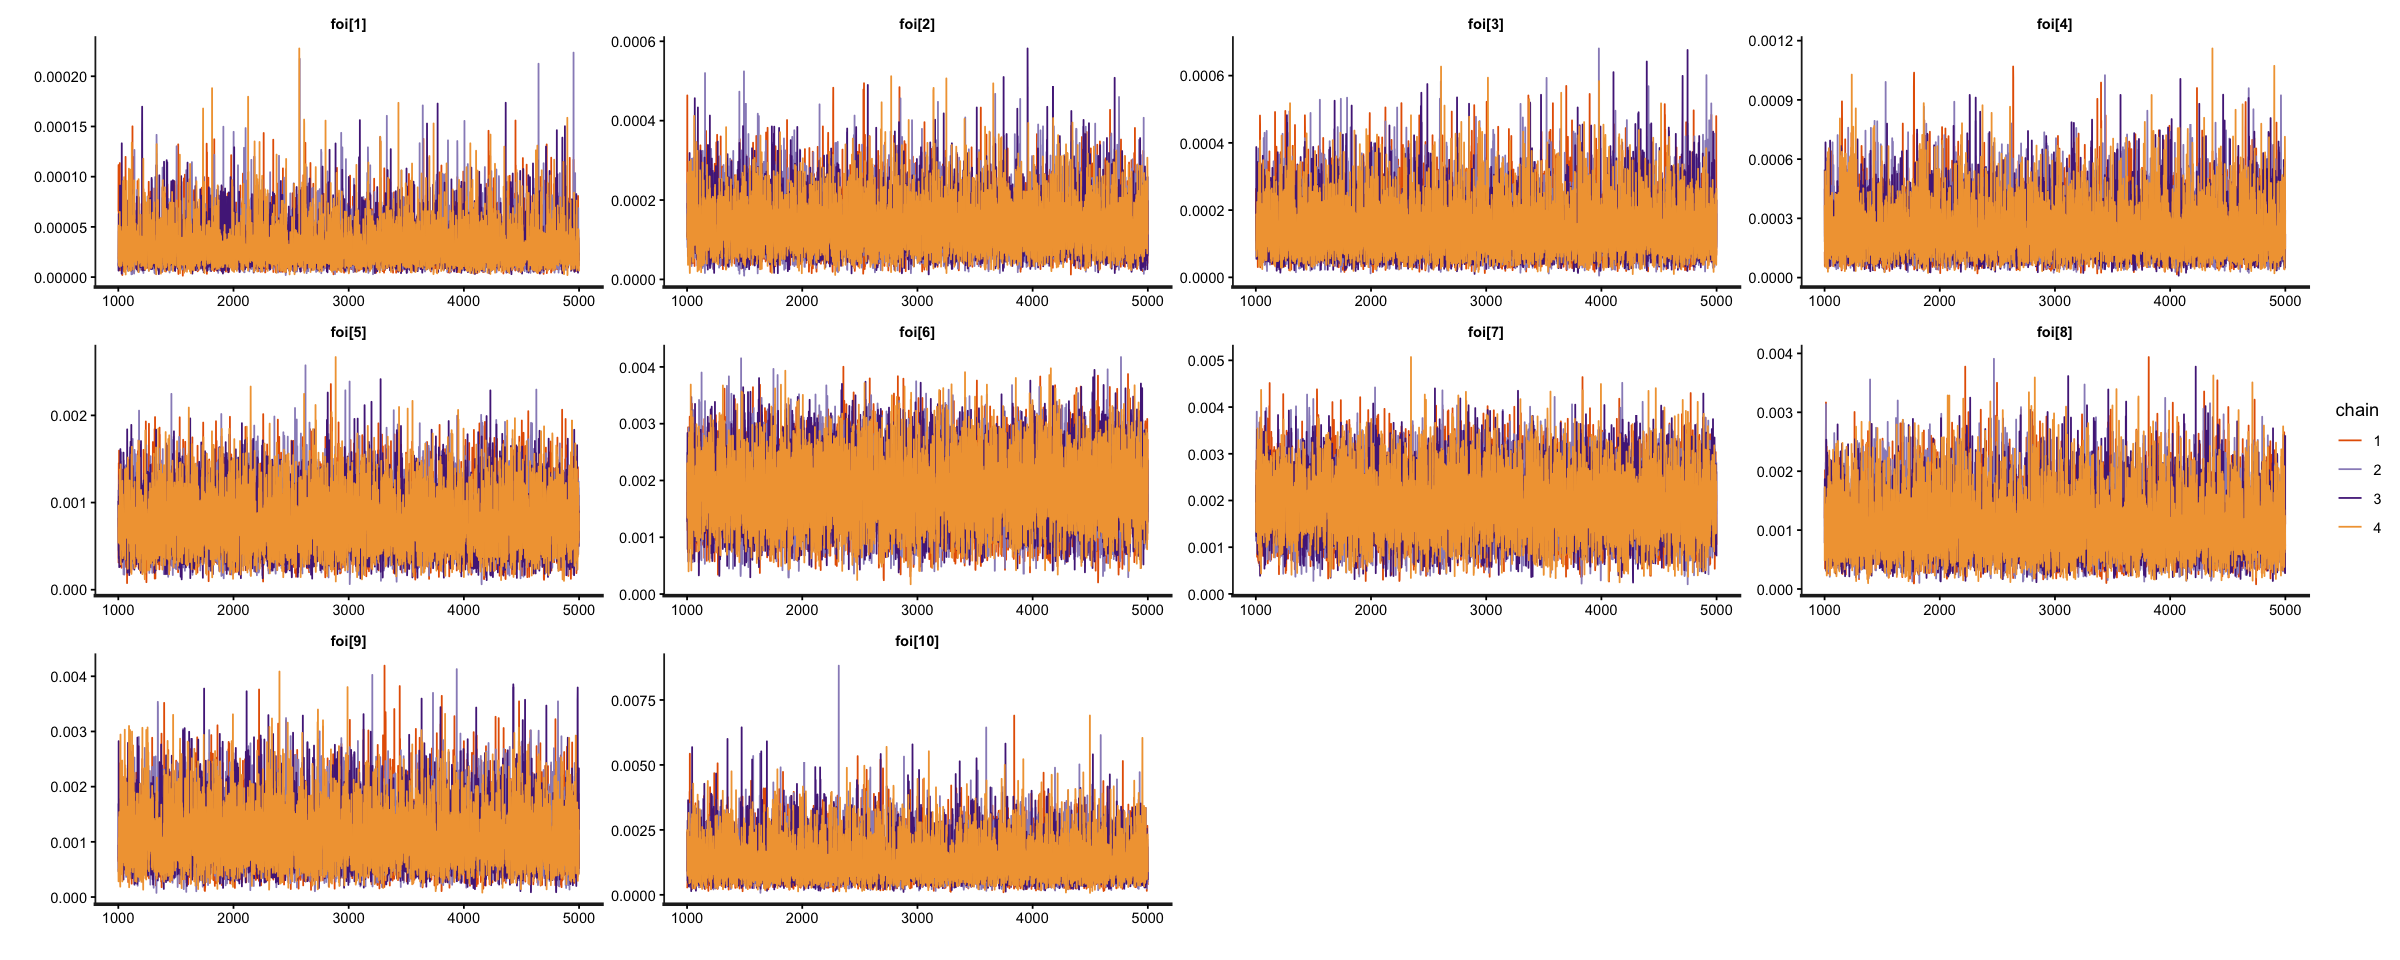

In [43]:
## sanity check for convergence
estimates_naive[[1]][[4]]
plots_naive_list[[1]][[4]]

In [99]:
estimates_naive[[1]][[4]]
estimates_adjusted[[1]][[4]]

param,idx,est_med,est_lower,est_25,est_75,est_upper,group,correct
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
foi[1],1,0.163591630,0.1489757028,0.158329226,0.168823498,0.178918972,Naive,0.178571429
foi[2],2,0.056999421,0.0281638106,0.046617346,0.067262927,0.085975264,Naive,0.053571429
foi[3],3,0.032227504,0.0105230813,0.023069399,0.042256054,0.061425857,Naive,0.035714286
foi[4],4,0.016061444,0.0047930229,0.010954376,0.022400527,0.036767914,Naive,0.017857143
foi[5],5,0.005165898,0.0013519866,0.003322968,0.007943148,0.016050361,Naive,0.005357143
foi[6],6,0.001752184,0.0004606989,0.001091375,0.002773805,0.006526604,Naive,0.001785714
foi[7],7,0.001743887,0.0004602068,0.001093209,0.002791417,0.006351560,Naive,0.001785714
foi[8],8,0.001758782,0.0004515539,0.001119168,0.002765565,0.006706798,Naive,0.001785714
foi[9],9,0.001781541,0.0004493896,0.001107141,0.002791051,0.006735193,Naive,0.001785714


param,idx,est_med,est_lower,est_25,est_75,est_upper,group,correct
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
foi[1],1,0.179389400,0.1641167207,0.174082815,0.184708577,0.194745161,Adjusted,0.178571429
foi[2],2,0.053165988,0.0248187671,0.042864332,0.063099107,0.082295130,Adjusted,0.053571429
foi[3],3,0.033717356,0.0112319068,0.024432388,0.043666831,0.062414373,Adjusted,0.035714286
foi[4],4,0.016026687,0.0047587872,0.010934190,0.022421970,0.036479567,Adjusted,0.017857143
foi[5],5,0.005166352,0.0013569622,0.003293497,0.007957367,0.016242036,Adjusted,0.005357143
foi[6],6,0.001768146,0.0004593096,0.001122133,0.002805939,0.006479158,Adjusted,0.001785714
foi[7],7,0.001760729,0.0004519124,0.001098029,0.002824178,0.006626846,Adjusted,0.001785714
foi[8],8,0.001770058,0.0004578172,0.001117602,0.002834277,0.006546840,Adjusted,0.001785714
foi[9],9,0.001760864,0.0004546103,0.001107082,0.002801682,0.006704953,Adjusted,0.001785714


Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_point()`).”
Warning message:
“Removed 8 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_segment()`).”
Warning message:
“Removed 16 rows containing missing values or values outside the scale range (`geom_segment()`).”


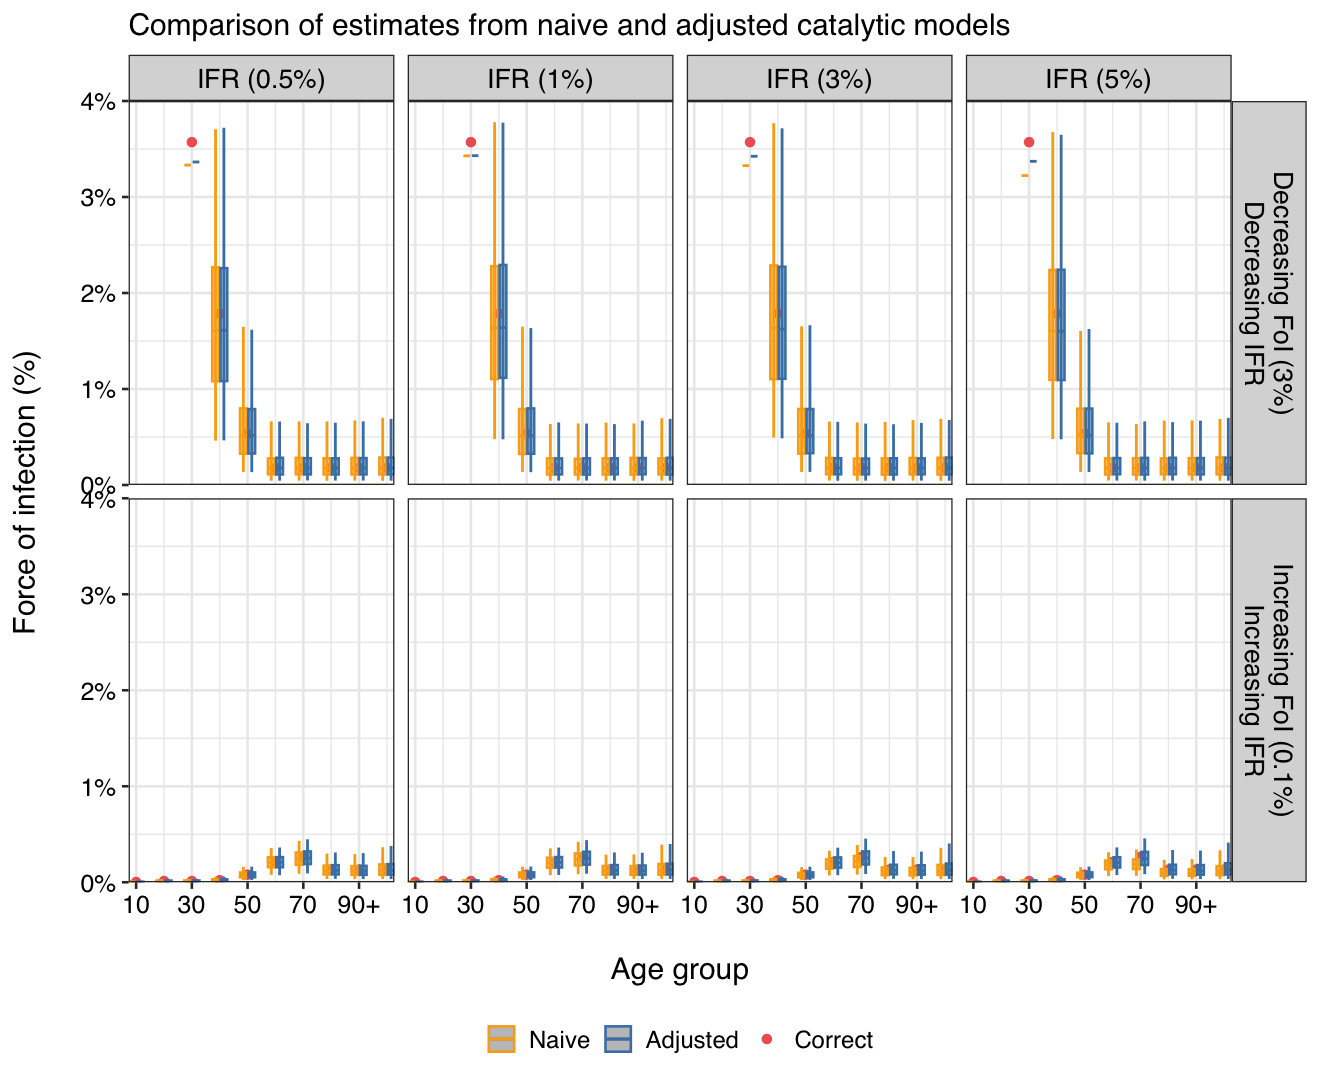

In [97]:
## ============================================================
## One-shot plotting code (copy & paste)
## Uses: estimates_naive, estimates_adjusted, IFR_class, target_IFR, target_foi
## Requires: dplyr, purrr, ggplot2, scales, magrittr
## ============================================================

library(dplyr)
library(purrr)
library(ggplot2)
library(scales)
library(magrittr)

## ---- 1) long-format helper
list_to_long <- function(est_list, IFR_class, target_IFR) {
  imap_dfr(est_list, function(sublist_i, i) {
    imap_dfr(sublist_i, function(df_l, l) {
      if (is.null(df_l) || nrow(df_l) == 0) return(NULL)

      df_l %>%
        mutate(
          age = idx,
          IFR_class = trimws(as.character(IFR_class[i])),
          IFR_level = paste0("IFR (", target_IFR[l], "%)")
        ) %>%
        dplyr::select(
          age, IFR_class, IFR_level, group, correct,
          foi = est_med, est_lower, est_upper, est_25, est_75
        )
    })
  })
}

## ---- 2) build df_est and df_true, then df_plot
df_est <- bind_rows(
  list_to_long(estimates_naive, IFR_class, target_IFR),
  list_to_long(estimates_adjusted, IFR_class, target_IFR)
)

df_true <- df_est %>%
  distinct(age, IFR_class, IFR_level, correct) %>%
  mutate(
    group = "Correct",
    foi = correct,
    est_lower = NA_real_, est_upper = NA_real_, est_25 = NA_real_, est_75 = NA_real_
  ) %>%
  dplyr::select(age, IFR_class, IFR_level, group, correct, foi, est_lower, est_upper, est_25, est_75)

df_plot <- bind_rows(df_est, df_true)

## ---- 3) add scenario labels + x positions
df_plot %<>%
  mutate(
    scenario = case_when(
      IFR_class == "Decreasing IFR" ~ paste0("Decreasing FoI (", target_foi[1], "%)\nDecreasing IFR"),
      IFR_class == "U-shaped IFR"   ~ paste0("Constant FoI (",   target_foi[2], "%)\nU-shaped IFR"),
      IFR_class == "Increasing IFR" ~ paste0("Increasing FoI (", target_foi[3], "%)\nIncreasing IFR"),
      TRUE ~ as.character(IFR_class)
    ),
    x_base = age,
    x_center = case_when(
      group == "Naive"    ~ x_base - 0.15,
      group == "Adjusted" ~ x_base + 0.15,
      TRUE ~ x_base
    ),
    IFR_level = factor(IFR_level, levels = paste0("IFR (", target_IFR, "%)")),
    group = factor(group, levels = c("Correct", "Naive", "Adjusted"))
  )

## ---- 4) plot
ggplot() +

  ## Correct: points (or change to geom_line if you prefer)
  geom_point(
    data = df_plot %>% filter(group == "Correct"),
    aes(x = age, y = foi, color = "Correct"),
    size = 2
  ) +

  ## Naive/Adjusted: 95% CI whiskers
  geom_segment(
    data = df_plot %>% filter(group != "Correct"),
    aes(x = x_center, xend = x_center, y = est_lower, yend = est_upper, color = group),
    linewidth = 0.8
  ) +

  ## Naive/Adjusted: IQR boxes
  geom_rect(
    data = df_plot %>% filter(group != "Correct"),
    aes(
      xmin = x_center - 0.12, xmax = x_center + 0.12,
      ymin = est_25, ymax = est_75, fill = group, color = group
    ),
    alpha = 0.4
  ) +

  ## Naive/Adjusted: median line
  geom_segment(
    data = df_plot %>% filter(group != "Correct"),
    aes(x = x_center - 0.12, xend = x_center + 0.12, y = foi, yend = foi, color = group),
    linewidth = 0.8
  ) +

  facet_grid(scenario ~ IFR_level) +

  scale_color_manual(values = c(
    "Correct" = "indianred2",
    "Naive" = "#FAAB18",
    "Adjusted" = "steelblue"
  )) +
  scale_fill_manual(values = c(
    "Naive" = "#FAAB18",
    "Adjusted" = "steelblue"
  ), guide = "none") +

  scale_x_continuous(
    expand = c(0, 0),
    breaks = c(1, 3, 5, 7, 9),
    labels = c("10", "30", "50", "70", "90+"),
    name = "\nAge group"
  ) +
  scale_y_continuous(
    limits = c(0, 0.04),
    expand = c(0, 0),
    labels = percent_format(accuracy = 1),
    name = "Force of infection (%)\n"
  ) +

  labs(title = "Comparison of estimates from naive and adjusted catalytic models") +

  theme_bw(base_size = 16) +
  theme(
    text = element_text(size = 18, family = "sans", color = "black"),
    axis.text = element_text(size = 15, family = "sans", color = "black"),
    legend.position = "bottom",
    legend.title = element_blank(),
    plot.title = element_text(size = 18, family = "sans", color = "black"),
    strip.text = element_text(size = 16, family = "sans", color = "black")
  )

In [98]:
df_plot %>% 
  count(scenario, IFR_level, group)

scenario,IFR_level,group,n
<chr>,<fct>,<fct>,<int>
Decreasing FoI (3%) Decreasing IFR,IFR (0.5%),Correct,10
Decreasing FoI (3%) Decreasing IFR,IFR (0.5%),Naive,10
Decreasing FoI (3%) Decreasing IFR,IFR (0.5%),Adjusted,10
Decreasing FoI (3%) Decreasing IFR,IFR (1%),Correct,10
Decreasing FoI (3%) Decreasing IFR,IFR (1%),Naive,10
Decreasing FoI (3%) Decreasing IFR,IFR (1%),Adjusted,10
Decreasing FoI (3%) Decreasing IFR,IFR (3%),Correct,10
Decreasing FoI (3%) Decreasing IFR,IFR (3%),Naive,10
Decreasing FoI (3%) Decreasing IFR,IFR (3%),Adjusted,10


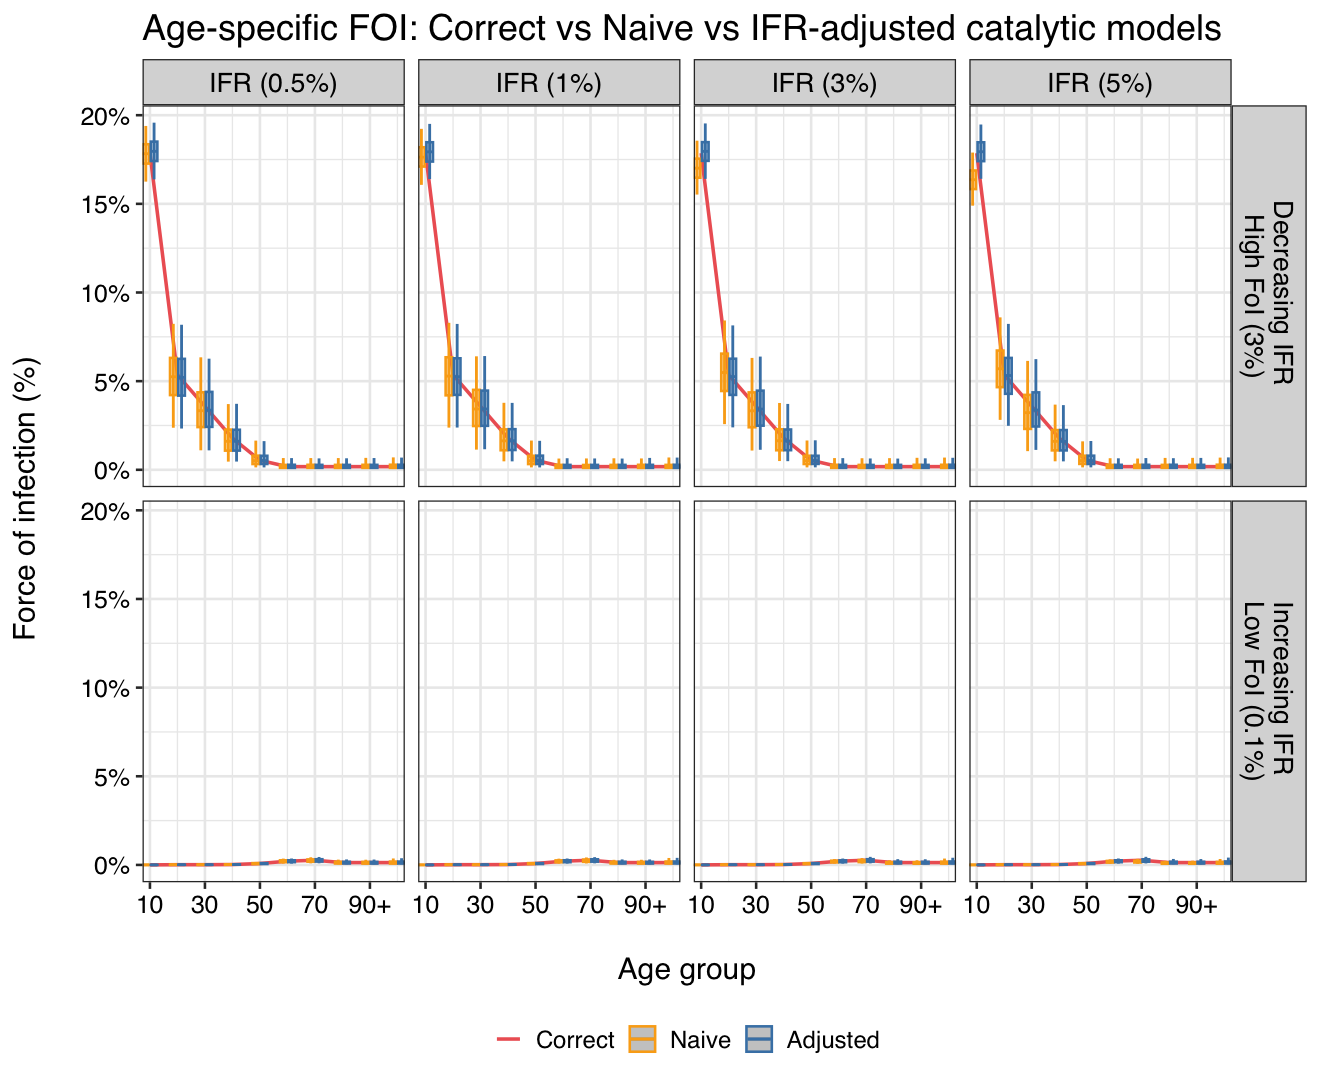

In [54]:
list_to_long <- function(est_list, IFR_class, target_IFR) {
    imap_dfr(est_list, function(sublist_i, i) {
        imap_dfr(sublist_i, function(df_l, l) {
            if (is.null(df_l) || nrow(df_l) == 0) return(NULL)

            df_l %>% mutate(age = idx, IFR_class = trimws(as.character(IFR_class[i])), IFR_level = paste0("IFR (", target_IFR[l], "%)")) %>%
            dplyr::select(age, IFR_class, IFR_level, group, correct, foi = est_med, est_lower, est_upper, est_25, est_75)})
    })
}

df_est <- bind_rows(list_to_long(estimates_naive, IFR_class, target_IFR), list_to_long(estimates_adjusted, IFR_class, target_IFR))

## ---- 2) Correct(=true FOI)도 같은 long 형태로 만들기
df_true <- df_est %>%
  distinct(age, IFR_class, IFR_level, correct) %>%
  mutate(group = "Correct",
         foi = correct,
         est_lower = NA_real_, est_upper = NA_real_, est_25 = NA_real_, est_75 = NA_real_) %>%
  select(age, IFR_class, IFR_level, group, correct,
         foi, est_lower, est_upper, est_25, est_75)

df_plot <- bind_rows(df_est, df_true)

## ---- 3) "3개 시나리오(대각선)" 라벨 만들기
class_lvls <- c("Decreasing IFR", "U-shaped IFR", "Increasing IFR")
if_levels  <- paste0("IFR (", target_IFR, "%)")

scenario_labels <- c(
  paste0("Decreasing IFR \nHigh FoI (", target_foi[1], "%)"),
  paste0("U-shaped IFR \nIntermediate FoI (", target_foi[2], "%)"),
  paste0("Increasing IFR \nLow FoI (", target_foi[3], "%)")
)

df_plot <- df_plot %>%
  mutate(
    IFR_class = factor(IFR_class, levels = class_lvls),
    IFR_level = factor(IFR_level, levels = if_levels),
    scenario = factor(as.character(IFR_class), levels = class_lvls, labels = scenario_labels),
    group = factor(group, levels = c("Correct", "Naive", "Adjusted"))
  )

## ---- 4) x 위치(naive/adjusted는 좌우로 살짝 벌림)
df_plot <- df_plot %>%
  mutate(
    x_base = age,
    x_center = case_when(
      group == "Naive"    ~ x_base - 0.15,
      group == "Adjusted" ~ x_base + 0.15,
      TRUE ~ x_base
    )
  )

## ---- 5) Plot
options(repr.plot.width = 11, repr.plot.height = 9)

ggplot(df_plot) +
  # Correct line (age-specific)
  geom_line(
    data = df_plot %>% filter(group == "Correct"),
    aes(x = x_base, y = foi, group = 1, color = group),
    linewidth = 1
  ) +
  # 95% CI whiskers for naive/adjusted
  geom_segment(
    data = df_plot %>% filter(group != "Correct"),
    aes(x = x_center, xend = x_center, y = est_lower, yend = est_upper, color = group),
    linewidth = 0.8
  ) +
  # IQR boxes
  geom_rect(
    data = df_plot %>% filter(group != "Correct"),
    aes(xmin = x_center - 0.12, xmax = x_center + 0.12,
        ymin = est_25, ymax = est_75, fill = group, color = group),
    alpha = 0.35
  ) +
  # median line inside box
  geom_segment(
    data = df_plot %>% filter(group != "Correct"),
    aes(x = x_center - 0.12, xend = x_center + 0.12, y = foi, yend = foi, color = group),
    linewidth = 0.8
  ) +
  facet_grid(scenario ~ IFR_level) +
  scale_color_manual(values = c("Correct" = "indianred2", "Naive" = "#FAAB18", "Adjusted" = "steelblue")) +
  scale_fill_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide = "none") +
  scale_x_continuous(
    expand = c(0, 0),
    breaks = c(1, 3, 5, 7, 9),
    labels = c("10", "30", "50", "70", "90+"),
    name = "\nAge group"
  ) +
  scale_y_continuous(
    labels = percent_format(accuracy = 1),
    name = "Force of infection (%) \n"
  ) +
  labs(title = "Age-specific FOI: Correct vs Naive vs IFR-adjusted catalytic models") +
  theme_bw(base_size = 16) +
  theme(
    text = element_text(size = 18, family = "sans", color = "black"),
    axis.text = element_text(size = 15, family = "sans", color = "black"),
    legend.position = "bottom",
    legend.title = element_blank(),
    strip.text = element_text(size = 16, family = "sans", color = "black")
  )

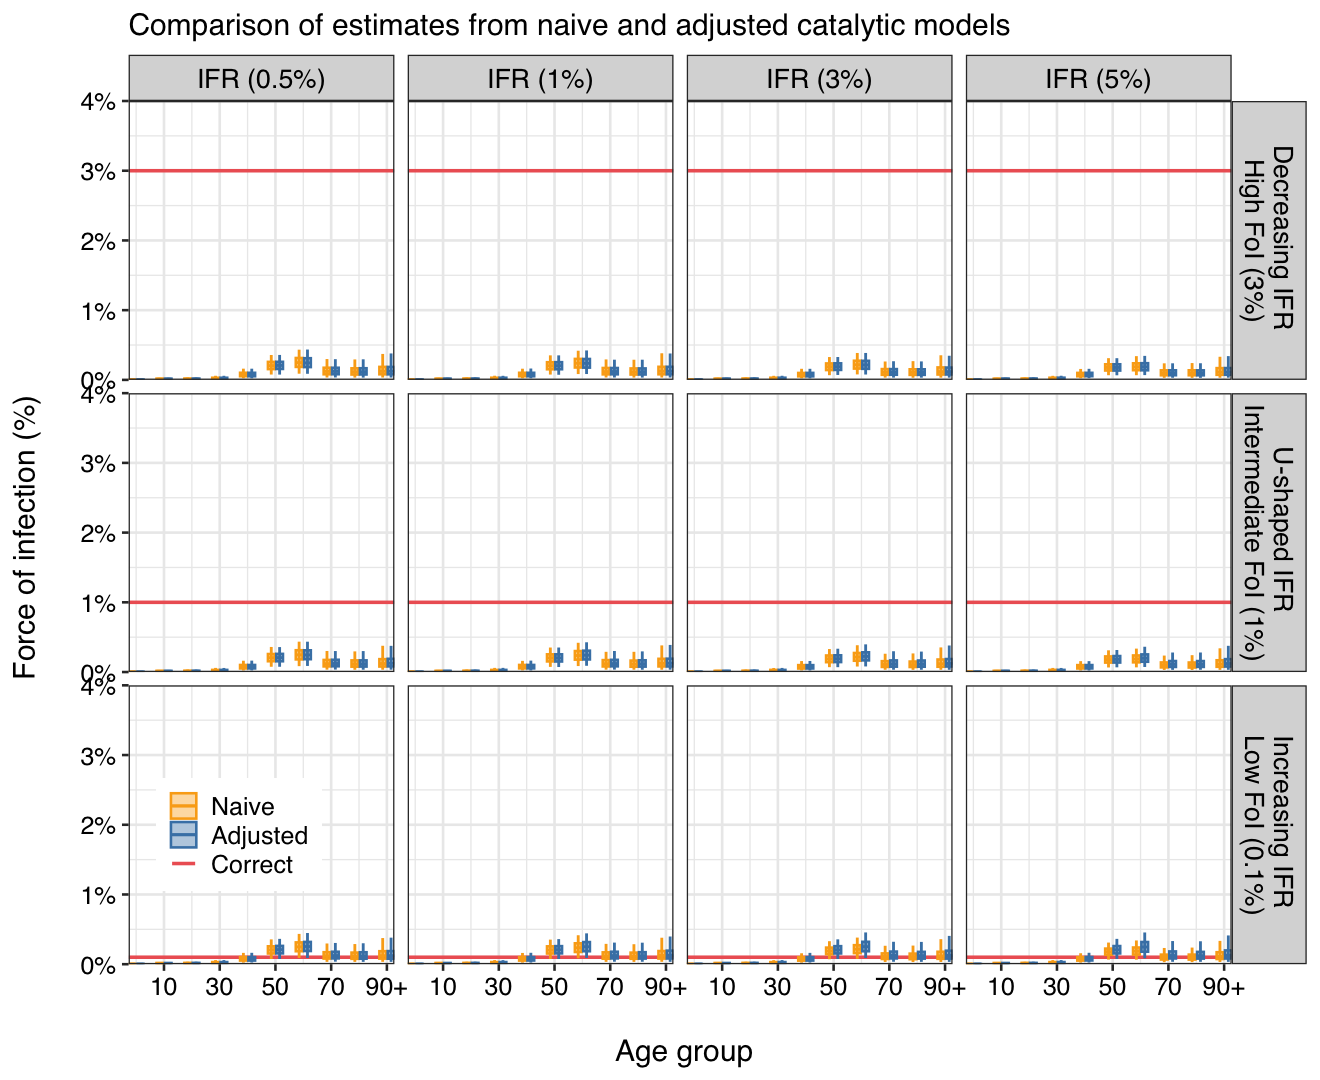

In [48]:
## plotting
n_age_groups <- length(foi_profile_list[[1]])

list_to_df <- function(est_list, IFR_class, target_IFR, group_name){
    imap_dfr(est_list, function(sublist_i, i){
        imap_dfr(sublist_i, function(df_l, l){
            if (is.null(df_l) || nrow(df_l) == 0) return(NULL)
            df_l %>% mutate(age = idx - 1, group = group_name,
                            IFR_class = trimws(as.character(IFR_class[i])), 
                            IFR_level = paste0("IFR (", target_IFR[l], "%)")) %>%
            dplyr::select(age, group, IFR_class, IFR_level, foi = est_med, est_lower, est_upper, est_25, est_75)})
    })
}
naive_df <- list_to_df(estimates_naive, IFR_class, target_IFR, "Naive")
adj_df <- list_to_df(estimates_adjusted, IFR_class, target_IFR, "Adjusted")

correct_df <- imap_dfr(IFR_class, function(cls, i){
    cls <- trimws(as.character(cls))
    foi_idx  <- as.integer(unname(foi_index_for_ifr[cls]))
    foi_true <- foi_profile_list[[foi_idx]][1]
    tibble(IFR_class = cls, foi = foi_true, group = "Correct")})

df_est <- bind_rows(naive_df, adj_df)

if_levels  <- paste0("IFR (", target_IFR, "%)")
if_labels  <- paste0(target_IFR, "%")
class_lvls <- c("Decreasing IFR", "U-shaped IFR", "Increasing IFR")

df_est %<>% mutate(IFR_level = factor(IFR_level, levels = if_levels, labels = paste0("IFR (", if_labels, ")")),
                   IFR_class = factor(IFR_class, levels = class_lvls),
                   group = factor(group, levels = c("Correct", "Naive", "Adjusted")))

correct_df %<>% mutate(IFR_class = factor(IFR_class, levels = class_lvls),
                       group = factor(group, levels = c("Correct", "Naive", "Adjusted")))

df_est_box <- df_est %>% 
mutate(x_base = age,
       x_center = case_when(group == "Naive" ~ x_base - 0.15, group == "Adjusted" ~ x_base + 0.15, TRUE ~ x_base),
       IFR_class_label = factor(IFR_class, levels = c("Decreasing IFR", "U-shaped IFR", "Increasing IFR"),
                                labels = c(paste0("Decreasing IFR \nHigh FoI (", target_foi[1], "%)"),
                                           paste0("U-shaped IFR \nIntermediate FoI (", target_foi[2], "%)"),
                                           paste0("Increasing IFR \nLow FoI (", target_foi[3], "%)"))))

merge(df_est_box, correct_df %>% dplyr::select(IFR_class, foi) %>% rename(correct = foi), 
      by = c("IFR_class"), all.x = TRUE) -> df_est_box

options(repr.plot.width = 11, repr.plot.height = 9)

ggplot() +
geom_hline(data = df_est_box, aes(yintercept = correct, color = "Correct"), linewidth = 1 ) +
geom_segment(data = df_est_box, aes(x = x_center, xend = x_center, y = est_lower, yend = est_upper, color = group), linewidth = 0.8) +
geom_rect(data = df_est_box, aes(xmin = x_center - 0.12, xmax = x_center + 0.12, 
                                 ymin = est_25, ymax = est_75, fill = group, color = group), alpha = 0.4) +
geom_segment(data = df_est_box, aes(x = x_center - 0.12, xend = x_center + 0.12, y = foi, yend = foi, color = group), linewidth = 0.8) +
facet_grid(IFR_class_label ~ IFR_level) +
scale_color_manual(values = c("Correct" = "indianred2", "Naive" = "#FAAB18", "Adjusted" = "steelblue"),
                   guide = guide_legend(override.aes = list( fill = c("#FAAB18", "steelblue", NA)))) +
scale_fill_manual(values = c("Correct" = "indianred2", "Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide = "none") +
scale_x_continuous(expand = c(0, 0), breaks = c(1, 3, 5, 7, 9), labels = c("10", "30", "50", "70", "90+"),
                   name = "\n Age group") +
scale_y_continuous(limits = c(0, 0.04), expand = c(0, 0), labels = scales::percent_format(accuracy = 1),
                   name = "Force of infection (%) \n") +
labs(title = "Comparison of estimates from naive and adjusted catalytic models") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.1, 0.15),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

# ggsave("figures/comparison_box.png", width = 10, height = 6, dpi = 300, bg = "white")

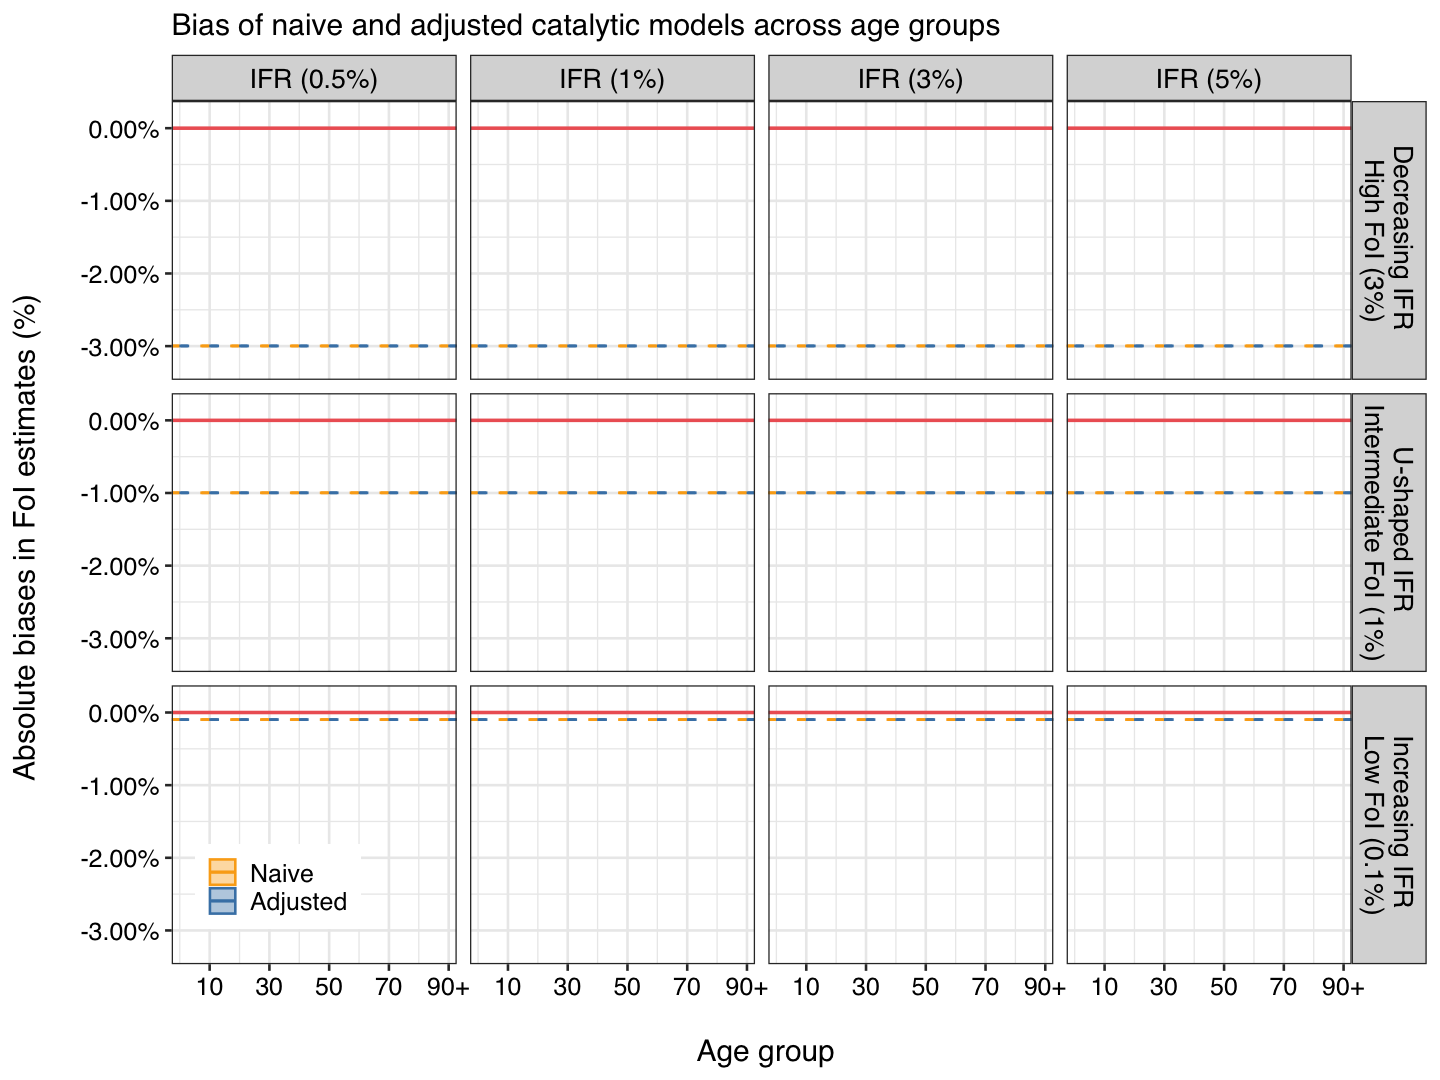

In [45]:
## plotting the absolute differences in the estimates
df_abs <- df_est_box %>%  mutate(foi_abs = foi - correct, est_lower_abs = est_lower - correct, est_upper_abs = est_upper - correct,
                                 est_25_abs = est_25 - correct, est_75_abs = est_75 - correct)

y_min_abs <- min(df_abs$est_lower_abs, na.rm = TRUE)
y_max_abs <- max(df_abs$est_upper_abs, na.rm = TRUE)
span_abs  <- y_max_abs - y_min_abs
y_lim_abs <- c(y_min_abs - 0.1 * span_abs, y_max_abs + 0.1 * span_abs)

options(repr.plot.width = 12, repr.plot.height = 9)

ggplot() +
geom_hline(yintercept = 0, color = "indianred2", linewidth = 1) +
geom_segment(data = df_abs, aes(x = x_center, xend = x_center, y = est_lower_abs, yend = est_upper_abs, color = group), linewidth = 0.8) +
geom_rect(data = df_abs, aes(xmin = x_center - 0.12, xmax = x_center + 0.12, 
                             ymin = est_25_abs, ymax = est_75_abs, fill = group, color = group), alpha = 0.4) +
geom_segment(data = df_abs, aes(x = x_center - 0.12, xend = x_center + 0.12,
                                y = foi_abs, yend = foi_abs, color = group), linewidth = 0.8) +
facet_grid(IFR_class_label ~ IFR_level) +
scale_color_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), breaks = c("Naive", "Adjusted"),
                   guide  = guide_legend(override.aes = list(fill = c("#FAAB18", "steelblue")))) +
scale_fill_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide  = "none") +
scale_x_continuous(expand = c(0, 0), breaks = c(1, 3, 5, 7, 9), labels = c("10", "30", "50", "70", "90+"), 
                   name = "\n Age group") +
scale_y_continuous(limits = y_lim_abs, labels = scales::percent_format(accuracy = 0.01), 
                   name = "Absolute biases in FoI estimates (%) \n") +
labs(title = "Bias of naive and adjusted catalytic models across age groups") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.09, 0.09),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

# ggsave("figures/comparison_box_abs_diff.png", width = 12, height = 9, dpi = 300, bg = "white")

Warning message:
“Removed 12 rows containing missing values or values outside the scale range (`geom_hline()`).”


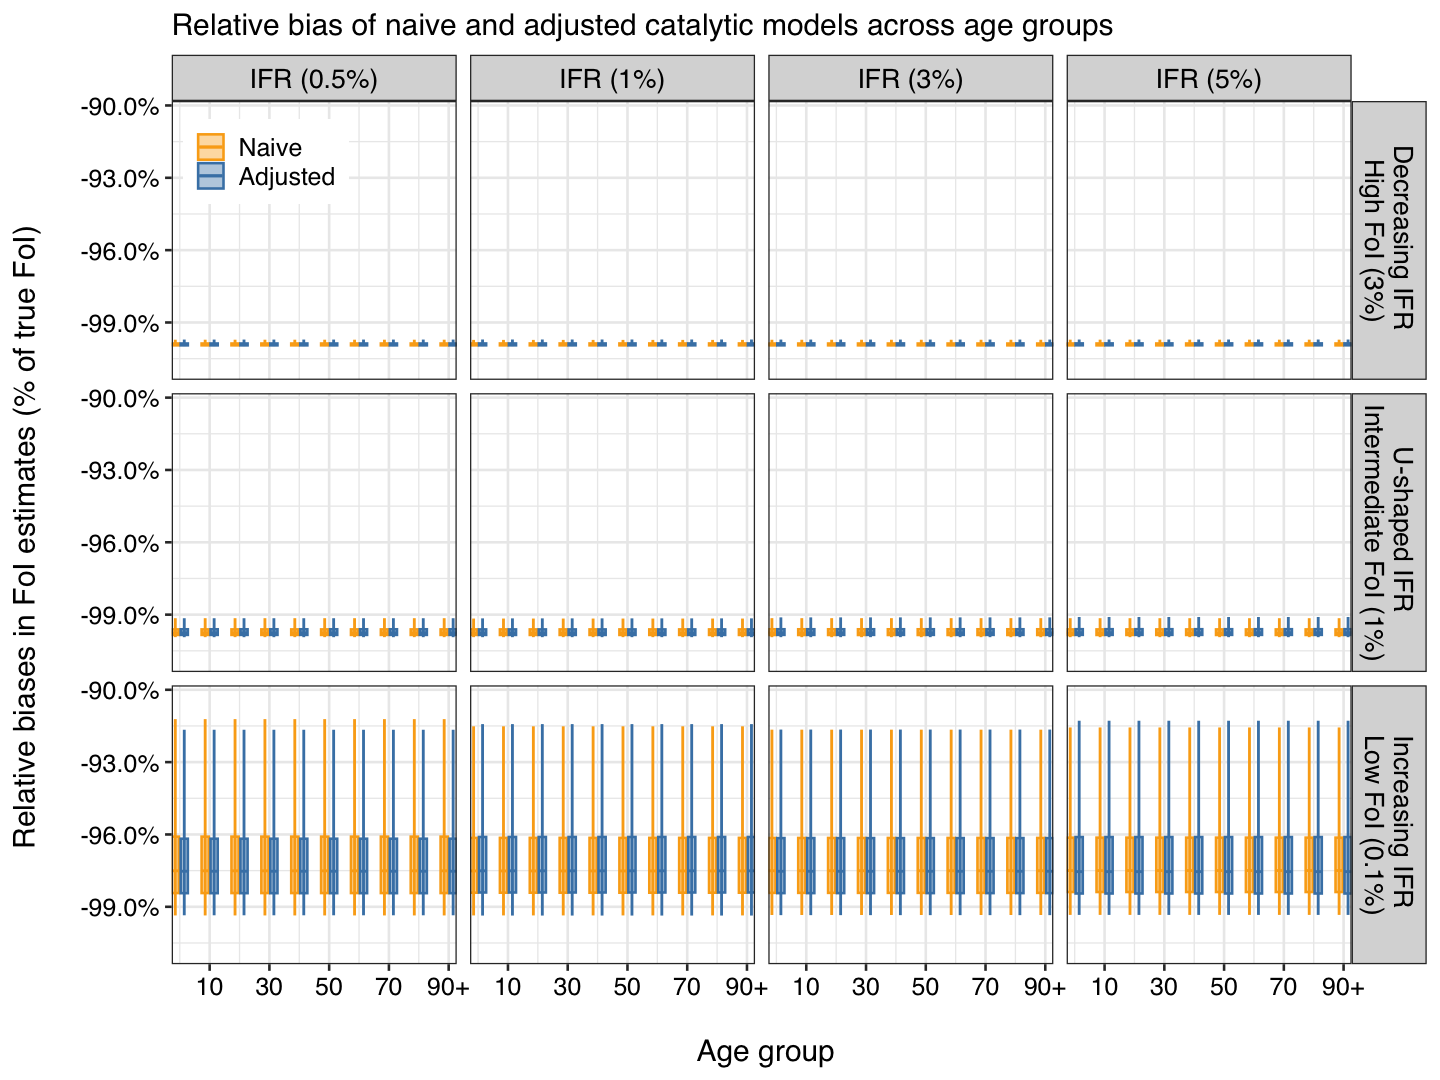

In [46]:
## plotting the relative differences in the estimates
df_rel <- df_est_box %>% mutate(foi_rel = (foi - correct) / correct, 
                                est_lower_rel = (est_lower - correct) / correct, est_upper_rel = (est_upper - correct) / correct,
                                est_25_rel = (est_25 - correct) / correct, est_75_rel = (est_75 - correct) / correct)

y_min_rel <- min(df_rel$est_lower_rel, na.rm = TRUE)
y_max_rel <- max(df_rel$est_upper_rel, na.rm = TRUE)
span_rel <- y_max_rel - y_min_rel
y_lim_rel <- c(y_min_rel - 0.1 * span_rel, y_max_rel + 0.1 * span_rel)

options(repr.plot.width = 12, repr.plot.height = 9)

ggplot() +
geom_hline(yintercept = 0, color = "indianred2", linewidth = 1) +
geom_segment(data = df_rel, aes(x = x_center, xend = x_center, y = est_lower_rel, yend = est_upper_rel, color = group), linewidth = 0.8) +
geom_rect(data = df_rel, aes(xmin = x_center - 0.12, xmax = x_center + 0.12,
                             ymin = est_25_rel, ymax = est_75_rel, fill = group, color = group), alpha = 0.4) +
geom_segment(data = df_rel, aes(x = x_center - 0.12, xend = x_center + 0.12,
                                y = foi_rel, yend = foi_rel, color = group), linewidth = 0.8) +
facet_grid(IFR_class_label ~ IFR_level) +
scale_color_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), breaks = c("Naive", "Adjusted"),
                   guide  = guide_legend(override.aes = list(fill = c("#FAAB18", "steelblue")))) +
scale_fill_manual(values = c("Naive" = "#FAAB18", "Adjusted" = "steelblue"), guide  = "none") +
scale_x_continuous(expand = c(0, 0), breaks = c(1, 3, 5, 7, 9), labels = c("10", "30", "50", "70", "90+"),
                   name = "\n Age group") +
scale_y_continuous(limits = y_lim_rel, labels = scales::percent_format(accuracy = 0.1),
                   name = "Relative biases in FoI estimates (% of true FoI) \n") +
labs(title = "Relative bias of naive and adjusted catalytic models across age groups") +
theme_bw(base_size = 16) +
theme(text = element_text(size = 18, family = "sans", color = "black"),
      axis.text = element_text(size = 15, family = "sans", color = "black"),
      legend.position = "inside", legend.position.inside = c(0.08, 0.93),
      legend.text = element_text(size = 15, color = "black"), legend.title = element_blank(),
      plot.title = element_text(size = 18, family = "sans", color = "black"),
      strip.text = element_text(size = 16, family = "sans", color = "black"),
      legend.key = element_rect(fill = "transparent"))

# ggsave("figures/comparison_box_rel_diff.png", width = 12, height = 9, dpi = 300, bg = "white")

In [47]:
system("jupyter nbconvert --to script catalyticmodel_comparison_varying.ipynb")